# HFSS Eigenmode Simulation of a CPW Resonator

This notebook demonstrates how to set up and run an eigenmode simulation
of a superconducting coplanar waveguide (CPW) resonator using PyAEDT
(Ansys HFSS Python interface).

Eigenmode analysis finds the natural resonant frequencies and Q-factors
of undriven electromagnetic structures - essential for designing
superconducting qubits and resonators.

**Prerequisites:**
- Ansys HFSS installed (requires license)
- Install hfss extras: `uv sync --extra hfss` or `pip install qpdk[hfss]`

**References:**
- PyAEDT Documentation: https://aedt.docs.pyansys.com/
- HFSS Eigenmode Examples: https://examples.aedt.docs.pyansys.com/

## Setup and Imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing quantum-rf-pdk...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import os
import tempfile
import time
from pathlib import Path

from ansys.aedt.core import Hfss, settings
from IPython.display import Image, display
from scipy.optimize import minimize_scalar

## Create a CPW Resonator Component

First, let's create a simple quarter-wave resonator using QPDK's component library.
We will use the `resonator_frequency` helper to find the length needed for a 5 GHz resonance.

Resonator bounding box: <bound method UMGeometricObject.bbox of Component(name=resonator_L6086p511634681758_M4_BSbend_circular_CScopla_89320bc0, ports=['o1', 'o2'], pins=[], instances=['straight_L966p0263269363516_CScoplanar_waveguide_WNone_N2_0_0', 'bend_circular_A180_R100_NNone_CScoplanar_waveguide_WNon_f5b64f4d_966026_0_M', 'straight_L966p0263269363516_CScoplanar_waveguide_WNone_N2_966026_-200000_A180', 'bend_circular_A180_R100_NNone_CScoplanar_waveguide_WNon_f5b64f4d_0_-200000_A180', 'straight_L966p0263269363516_CScoplanar_waveguide_WNone_N2_0_-400000', 'bend_circular_A180_R100_NNone_CScoplanar_waveguide_WNon_f5b64f4d_966026_-400000_M', 'straight_L966p0263269363516_CScoplanar_waveguide_WNone_N2_966026_-600000_A180', 'bend_circular_A180_R100_NNone_CScoplanar_waveguide_WNon_f5b64f4d_0_-600000_A180', 'straight_L966p0263269363516_CScoplanar_waveguide_WNone_N2_0_-800000', 'rectangle_gdsfactorypcomponentspshapesprectangle_S6_22__2d316d18_-3000_0'], locked=True, kcl=DEFAULT)>
Expected qua

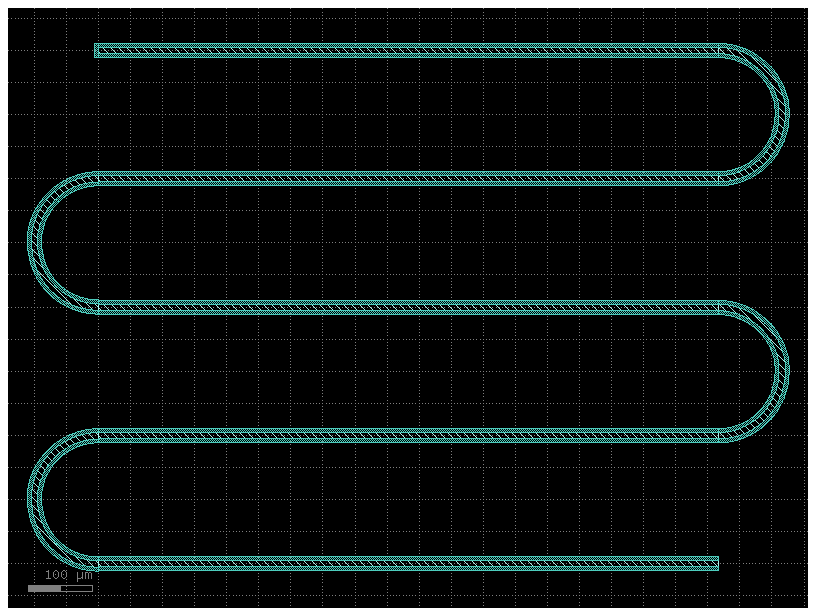

In [3]:
from qpdk import PDK
from qpdk.cells.resonator import resonator
from qpdk.config import PATH
from qpdk.models.resonator import resonator_frequency
from qpdk.simulation import HFSS, prepare_component_for_aedt
from qpdk.tech import coplanar_waveguide

PDK.activate()

# Create a meandering quarter-wave resonator
# With default CPW dimensions (10µm width, 6µm gap)
cpw_cross_section = coplanar_waveguide(width=10, gap=6)

# Calculate length for 5 GHz target
target_f_hz = 5e9


# Use scipy.optimize to find the exact length for the target frequency
def objective(length):
    """Objective function to find the exact length for the target frequency.

    Returns:
        Absolute difference between calculated and target frequency.
    """
    f_res = resonator_frequency(
        length=length, cross_section=cpw_cross_section, is_quarter_wave=True
    )
    return abs(f_res - target_f_hz)


result = minimize_scalar(objective, bounds=(1000, 10000), method="bounded")
current_length = result.x

res_component = resonator(
    length=current_length,
    meanders=4,  # Number of meander turns
    cross_section=cpw_cross_section,
    open_start=True,  # Open end (voltage antinode)
    open_end=False,  # Shorted end (voltage node)
)

# Visualize the component
res_component.plot()
print(f"Resonator bounding box: {res_component.bbox}")
print(f"Expected quarter-wave frequency: ~{target_f_hz / 1e9:.2f} GHz")
print(f"Calculated length: {current_length:.1f} µm")

## Initialize HFSS Project

Now we'll set up an HFSS project for eigenmode analysis.
The simulation will find the natural resonant modes of the structure.

**Note:** This section requires Ansys HFSS to be installed and licensed.
The code is wrapped in a try-except block for demonstration purposes.

In [4]:
# Configuration for HFSS simulation
EIGENMODE_CONFIG = {
    "min_frequency_ghz": 3.0,  # Start searching from 3 GHz
    "num_modes": 1,  # Find 1 eigenmode
    "max_passes": 15,  # Maximum adaptive mesh passes
    "min_passes": 2,
    "percent_refinement": 30,
}

## Build HFSS Model (Example Code)

The following code demonstrates how to:
1. Create an HFSS project with eigenmode solution type
2. Build the CPW geometry in HFSS
3. Add substrate and boundary conditions
4. Configure eigenmode analysis
5. Run the simulation and extract results

```{note}
This code requires Ansys HFSS to be installed. The example below shows
the structure of a complete simulation workflow.
```

In [5]:
# Example HFSS eigenmode simulation workflow
# This code block demonstrates the full workflow but requires HFSS license

# Ensure Ansys path is set so PyAEDT can find it
ansys_default_path = "/usr/ansys_inc/v252/AnsysEM"
if "ANSYSEM_ROOT252" not in os.environ and Path(ansys_default_path).exists():
    os.environ["ANSYSEM_ROOT252"] = ansys_default_path

settings.use_grpc_uds = False


# Create temporary directory for project
temp_dir = tempfile.TemporaryDirectory(suffix=".ansys_qpdk")
project_path = Path(temp_dir.name) / "resonator_eigenmode.aedt"

# Initialize HFSS with Eigenmode solution
hfss = Hfss(
    project=str(project_path),
    design="CPW_Resonator",
    solution_type="Eigenmode",
    non_graphical=False,
    new_desktop=True,
    version="2025.2",
)
hfss.modeler.model_units = "um"

print(f"HFSS project created: {hfss.project_file}")
print(f"Design name: {hfss.design_name}")
print(f"Solution type: {hfss.solution_type}")

PyAEDT INFO: Python version 3.12.13 (main, Mar  3 2026, 14:59:34) [Clang 21.1.4 ].


PyAEDT INFO: PyAEDT version 0.26.2.


PyAEDT INFO: Initializing new Desktop session.


PyAEDT INFO: AEDT version 2025.2.


PyAEDT INFO: New AEDT session is starting on gRPC port 40607.


...

PyAEDT INFO: Project resonator_eigenmode has been created.


PyAEDT INFO: Added design 'CPW_Resonator' of type HFSS.


PyAEDT INFO: AEDT objects correctly read


PyAEDT INFO: Modeler class has been initialized! Elapsed time: 0m 0sec


HFSS project created: /tmp/tmp2vcqocpe.ansys_qpdk/resonator_eigenmode.aedt
Design name: CPW_Resonator
Solution type: Eigenmode


## Build CPW Geometry in HFSS

Import the gdsfactory component geometry into HFSS using native GDS import.
This uses `Hfss.import_gds_3d` which automatically handles 3D layer mapping
based on the QPDK LayerStack.

In [6]:
# Prepare component for export
res_component = prepare_component_for_aedt(res_component, margin_draw=200)

# Initialize HFSS wrapper
hfss_sim = HFSS(hfss)

# Import the component geometry using native GDS import
success = hfss_sim.import_component(res_component, import_as_sheets=True)
print(f"GDS import successful: {success}")

# Add substrate below the component
substrate_name = hfss_sim.add_substrate(
    res_component,
    thickness=500.0,
    material="silicon",
)
print(f"Created substrate: {substrate_name}")

# Add air region with PEC boundary for eigenmode analysis
air_region_name = hfss_sim.add_air_region(
    res_component,
    height=500.0,
    substrate_thickness=500.0,
    pec_boundary=True,
)
print(f"Created air region with PEC boundary: {air_region_name}")

PyAEDT INFO: GDS layer imported with elevations and thickness.


PyAEDT INFO: Boundary Perfect E PEC_Sheets has been created.


GDS import successful: True
PyAEDT INFO: Materials class has been initialized! Elapsed time: 0m 0sec


Created substrate: Substrate


PyAEDT INFO: Boundary Perfect E PEC_Boundary has been created.


Created air region with PEC boundary: AirRegion


### Geometry Verification
Here is the 3D geometry of the CPW resonator in HFSS for eigenmode analysis.

![HFSS geometry](../docs/_static/images/hfss_eigenmode_resonator_geom.jpg)

PyAEDT INFO: Parsing /tmp/tmp2vcqocpe.ansys_qpdk/resonator_eigenmode.aedt.


PyAEDT INFO: File /tmp/tmp2vcqocpe.ansys_qpdk/resonator_eigenmode.aedt correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: aedt file load time 0.0023860931396484375


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: PostProcessor class has been initialized! Elapsed time: 0m 0sec


PyAEDT INFO: Post class has been initialized! Elapsed time: 0m 0sec


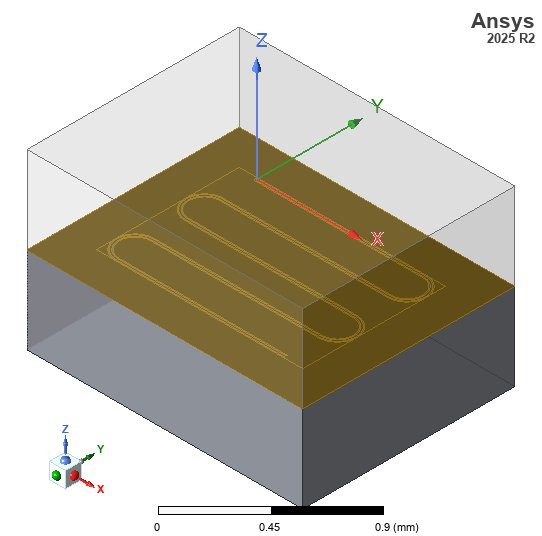

In [7]:
# Ensure HFSS model fits the screen
hfss.modeler.fit_all()

# Save screenshot
img_dir = PATH.repo / "docs" / "_static" / "images"
img_dir.mkdir(parents=True, exist_ok=True)
hfss_img_path = img_dir / "hfss_eigenmode_resonator_geom.jpg"
hfss.post.export_model_picture(
    full_name=str(hfss_img_path), show_axis=True, show_grid=False, show_ruler=True
)

# Display in notebook
display(Image(filename=str(hfss_img_path)))

## Configure Eigenmode Analysis

Set up the eigenmode solver to find resonant frequencies starting from 3 GHz.

In [8]:
# Create eigenmode setup
setup = hfss.create_setup(name="EigenmodeSetup")

setup.props["MinimumFrequency"] = f"{EIGENMODE_CONFIG['min_frequency_ghz']}GHz"
setup.props["NumModes"] = EIGENMODE_CONFIG["num_modes"]
setup.props["MaximumPasses"] = EIGENMODE_CONFIG["max_passes"]
setup.props["MinimumPasses"] = EIGENMODE_CONFIG["min_passes"]
setup.props["PercentRefinement"] = EIGENMODE_CONFIG["percent_refinement"]
setup.props["ConvergeOnRealFreq"] = True
setup.props["MaxDeltaFreq"] = 0.1  # 0.1% convergence criterion

setup.update()
print("Eigenmode setup configured:")
print(f"  - Min frequency: {EIGENMODE_CONFIG['min_frequency_ghz']} GHz")
print(f"  - Number of modes: {EIGENMODE_CONFIG['num_modes']}")
print(f"  - Max passes: {EIGENMODE_CONFIG['max_passes']}")

Eigenmode setup configured:
  - Min frequency: 3.0 GHz
  - Number of modes: 1
  - Max passes: 15


## Run Simulation

Execute the eigenmode analysis. This may take several minutes depending
on the mesh complexity and number of modes.

In [9]:
print("Starting eigenmode analysis...")
print("(This may take several minutes)")

# Save project before analysis
hfss.save_project()

# Run the analysis
start_time = time.time()
success = hfss.analyze_setup("EigenmodeSetup", cores=4)
elapsed = time.time() - start_time

if not success:
    print("\nERROR: HFSS simulation failed!")
    # Try to get more info from HFSS logs if possible
else:
    print(f"Analysis completed in {elapsed:.1f} seconds")

Starting eigenmode analysis...
(This may take several minutes)
PyAEDT INFO: Project resonator_eigenmode Saved correctly


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


PyAEDT INFO: Solving design setup EigenmodeSetup


PyAEDT INFO: Design setup EigenmodeSetup solved correctly in 0.0h 1.0m 37.0s


PyAEDT INFO: Key Desktop/ActiveDSOConfigurations/HFSS correctly changed.


Analysis completed in 97.5 seconds


## Extract Results

Get the eigenmode frequencies and Q-factors from the simulation.

In [10]:
# Extract results using the wrapper
sim_results = hfss_sim.get_eigenmode_results("EigenmodeSetup")

print("\n=== Eigenmode Results ===")
print("-" * 40)

results = {
    "frequencies_ghz": sim_results["frequencies"],
    "q_factors": sim_results["q_factors"],
}

if not results["frequencies_ghz"]:
    print("No eigenmodes found. Check simulation logs and geometry.")
else:
    for i, (freq_ghz, q_factor) in enumerate(
        zip(results["frequencies_ghz"], results["q_factors"]), 1
    ):
        print(f"Mode {i}: f = {freq_ghz:.4f} GHz, Q = {q_factor:.1f}")

print("-" * 40)

# Compare with analytical estimate
expected_freq = target_f_hz / 1e9  # Target frequency
if results["frequencies_ghz"]:
    actual_freq = results["frequencies_ghz"][0]
    error_percent = abs(actual_freq - expected_freq) / expected_freq * 100
    print("\nComparison with analytical estimate:")
    print(f"  Expected (target): {expected_freq:.4f} GHz")
    print(f"  Simulated:         {actual_freq:.4f} GHz")
    print(f"  Difference:        {error_percent:.1f}%")

PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly loaded. Elapsed time: 0m 0sec


PyAEDT INFO: Solution Correctly parsed. Elapsed time: 0m 0sec



=== Eigenmode Results ===
----------------------------------------
Mode 1: f = 4.8350 GHz, Q = 0.0
----------------------------------------

Comparison with analytical estimate:
  Expected (target): 5.0000 GHz
  Simulated:         4.8350 GHz
  Difference:        3.3%


~/dev/quantum-rf-pdk/.venv/lib/python3.12/site-packages/ansys/aedt/core/visualization/post/solution_data.py:648: UserWarning: Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.
  warnings.warn("Method `data_real` is deprecated. Use :func:`get_expression_data` property instead.")


## Plot Field Solution

We can visualize the electric field magnitude of the first eigenmode on the surface of the substrate.

![HFSS field](../docs/_static/images/hfss_eigenmode_resonator_field.jpg)

PyAEDT INFO: Active Design set to CPW_Resonator


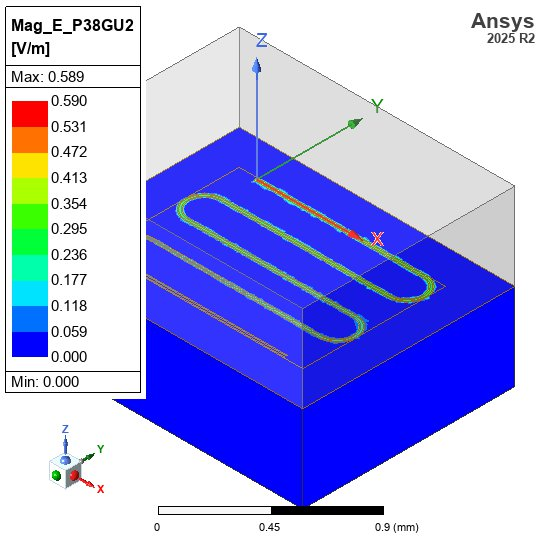

In [11]:
# Ensure the model fits the screen
hfss.modeler.fit_all()

# Create a surface field plot of the electric field magnitude on the substrate
plot = hfss.post.create_fieldplot_surface(
    assignment=[substrate_name], quantity="Mag_E", setup=f"{setup.name} : LastAdaptive"
)

# Export the field plot picture
hfss_field_img_path = img_dir / "hfss_eigenmode_resonator_field.jpg"
if plot:
    hfss.post.export_model_picture(
        full_name=str(hfss_field_img_path),
        show_axis=True,
        show_grid=False,
        show_ruler=True,
        field_selections="all",
    )
else:
    print("Failed to create field plot")

# Display in notebook
display(Image(filename=str(hfss_field_img_path)))

## Cleanup

Close HFSS and clean up temporary files.

In [12]:
# Save and close
hfss.save_project()
# hfss.release_desktop()
time.sleep(2)  # Allow HFSS to shut down

# Clean up temp directory
temp_dir.cleanup()
print("HFSS session closed and temporary files cleaned up")

PyAEDT INFO: Project resonator_eigenmode Saved correctly


HFSS session closed and temporary files cleaned up


## Summary

This notebook demonstrated:

1. **Component Creation**: Using QPDK's `resonator` cell to create a
   meandering CPW quarter-wave resonator

2. **HFSS Setup**: Initializing PyAEDT with eigenmode solution type

3. **Geometry Building**: Converting gdsfactory polygons to HFSS 3D geometry
   with proper material assignments (PEC for superconducting metal)

4. **Eigenmode Analysis**: Configuring and running the solver to find
   resonant frequencies and Q-factors

5. **Results Extraction**: Getting mode frequencies and Q-factors for
   comparison with analytical models

**Key Points for Superconducting Resonators:**
- Use PerfectE (PEC) boundaries for superconducting metals at cryogenic temps
- Silicon substrate with εᵣ ≈ 11.45 significantly affects resonance frequency
- Q-factors from eigenmode analysis represent unloaded Q (internal losses only)
- Coupling to external circuits reduces measured Q (loaded Q)

**Next Steps:**
- Compare eigenmode results with SAX circuit simulations
- Add lossy materials to estimate realistic Q-factors
- Study coupling effects with driven modal simulations